Task 3: Clustering (Unsupervised Learning)

Desciption: Implement K-Means clustering to group data points into clusters without labels (e.g.,customer segmentation).


Objectives:

.Apply K-Means clustering to the dataset.

.Use the elbow method or silhouette score to determine the optimal number of clusters.

.Visualize the clusters in 2D space using PCA or t-SNE for dimensionality reduction.

.Interpret the clustering results and summarize key findings.

.Tools: Python, scikit-learn, matplotlib, seaborn.


| Task requirement           | What  to do                                         |
| -------------------------- | --------------------------------------------------- |
| Apply K-Means              | Train `KMeans` on the dataset                       |
| Determine optimal clusters | Use *Elbow Method* and/or *Silhouette Score*        |
| Visualize clusters         | Use *PCA* to reduce the features to 2D              |
| Interpret results          | Examine cluster sizes, centers, and characteristics |
| Summarize findings         | Write a concise report                              |
| Tools                      | Python, pandas, scikit-learn, matplotlib, seaborn   |




Load the data from Scikit Learn - Iris Data set

In [2]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Checking the Structure of the Dataset

In [3]:
df.shape

(150, 5)

Checking for Missing Values

In [4]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Preparing the data for K-Means

N.B.: Here K-Means must not receive the species column because that is the known label. We're doing unsupervised learning, so the algorithm should discover the groups itself.

In [6]:
X = df.drop("species", axis=1)
X.shape

(150, 4)

Scaling the Features

Why are we scaling?

The four measurements don't necessarily have identical numerical ranges. K-Means uses distance to determine which observations belong together, so a feature with a larger scale could disproportionately influence the clustering.

Standardization puts the features on a comparable scale.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled.shape

(150, 4)

Determining the appropriate number of clusters.

Using Elbow Method

I don't want to arbitrarily tell K-Means, "give me 3 clusters." Instead, I'll test several possible values of K and examine how the clustering performance changes.

The Elbow Method uses inertia (within-cluster sum of squares). I'll look for the point where adding more clusters produces diminishing improvement — the "elbow."

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

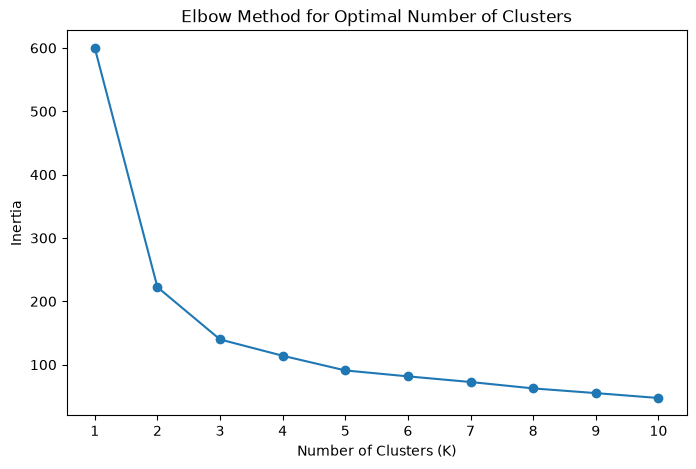

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(1, 11))
plt.show()

Interpreting the Elbow Plot

Notice the sharp reductions in inertia:

K = 1 → 2: very large improvement
K = 2 → 3: substantial improvement
K = 3 → 4: much smaller improvement
After K = 3, the curve begins to flatten considerably.

So the elbow is around K = 3.

This is our evidence-based choice for the number of clusters.

Apply K-Means with 3 clusters

Now we'll train the final K-Means model using K = 3.

In [10]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [11]:
#attach the discovered cluster assignments to our dataframe:
df["Cluster"] = clusters

#then check how many observations ended up in each cluster:

df["Cluster"].value_counts().sort_index()

Cluster
0    53
1    50
2    47
Name: count, dtype: int64

At this point, K-Means has never seen the species column.

It has simply looked at the four standardized flower measurements and independently grouped the 150 observations into three clusters.

Silhouette Score

This allows us to use the Elbow Method or Silhouette Score. Since I've already used the Elbow Method, calculating the Silhouette Score gives an additional quantitative check.


The Silhouette Score ranges from -1 to 1:

.Close to 1 → clusters are well 

.Around 0 → clusters overlap

.Negative values → observations may have been assigned to the wrong clusters

In [12]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.45994823920518646


#Summary

Elbow Method: suggests K = 3

Silhouette Score: 0.4599

Clusters: 3

Cluster sizes: 53, 50, 47

PCA(Principal Component Analysis) for 2D visualization- This will reduce the four standardized features to two principal components.

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Reduced number of features:", X_pca.shape[1])

Original number of features: 4
Reduced number of features: 2


In [14]:
#checking how much information the two components retain - how much of the original four-dimensional information is represented by our 2D visualization.

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.72962445 0.22850762]
Total explained variance: 0.9581320720000165


#So our 2D PCA plot retains about 95.8% of the variance in the original four features. That's excellent for a 2D visualization.

# Visual Display of the Cluster in 2D

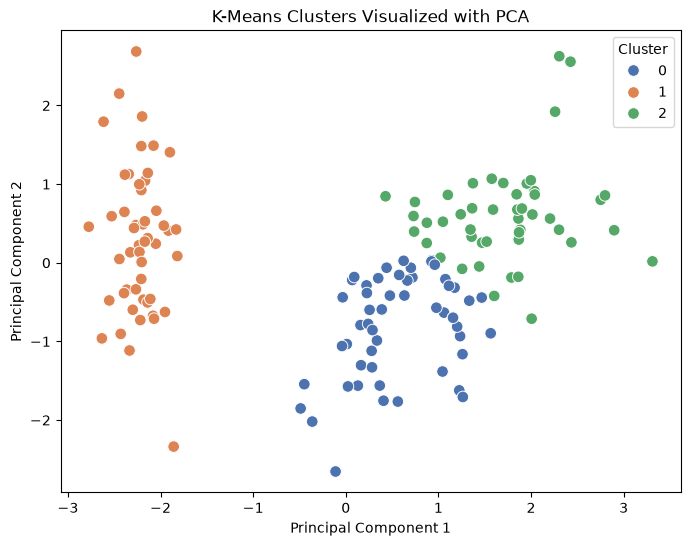

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=clusters,
    palette="deep",
    s=70
)

plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

# Summary of the 2D Visualization Plot
The 2D PCA visualization shows that the products form three clusters with relatively balanced sizes. The clusters exhibit some separation, although there is also some overlap between them. This is consistent with the silhouette score of approximately 0.46, indicating moderate clustering quality. Since the first two principal components explain approximately 95.8% of the total variance, the 2D visualization provides a strong representation of the original feature space.

Examine Cluster Characterisitics

In [16]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
Cluster,,,,,
0,5.801887,2.673585,4.369811,1.413208,1.264151
1,5.006000,3.428000,1.462000,0.246000,0.000000
2,6.780851,3.095745,5.510638,1.972340,1.765957


| Cluster | Main characteristics                                                                           |
| ------- | ---------------------------------------------------------------------------------------------- |
| **0**   | Intermediate petal measurements: petal length ≈ 4.37 cm, petal width ≈ 1.41 cm                 |
| **1**   | Smallest measurements, especially petals: petal length ≈ 1.46 cm, petal width ≈ 0.25 cm        |
| **2**   | Largest measurements overall, especially petals: petal length ≈ 5.51 cm, petal width ≈ 1.97 cm |


In [17]:
cluster_summary = df.groupby("Cluster").mean(
    numeric_only=True
).drop(columns=["species"], errors="ignore")

cluster_summary

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Cluster,,,,
0,5.801887,2.673585,4.369811,1.413208
1,5.006000,3.428000,1.462000,0.246000
2,6.780851,3.095745,5.510638,1.972340


Compare the clusters with the actual species.

In [18]:
pd.crosstab(df["Cluster"], df["species"])

species,0,1,2
Cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


In [19]:
#quantifying how many observations were placed into a cluster that corresponds to their dominant species.

cluster_species = pd.crosstab(df["Cluster"], df["species"])

correct = (
    cluster_species.max(axis=1).sum()
)

total = cluster_species.values.sum()

accuracy = correct / total

print("Cluster-to-species agreement:", accuracy)

Cluster-to-species agreement: 0.8333333333333334


Clustering Results

K-Means clustering divided the Iris dataset into three clusters with 53, 50, and 47 observations respectively. The clusters showed moderate separation, as indicated by a silhouette score of approximately 0.46.

The cluster characteristics showed that Cluster 1 contained flowers with the smallest petal measurements, Cluster 0 represented flowers with intermediate measurements, and Cluster 2 contained flowers with the largest petal measurements.

Comparison with the known species labels showed that all 50 observations of Species 0 were assigned to Cluster 1, while Species 1 and Species 2 had some overlap between Clusters 0 and 2. The cluster-to-species agreement was 83.33%, indicating that the unsupervised clustering captured a substantial amount of the structure present in the known species.

Overall, the K-Means model successfully identified meaningful groups based on the flower measurements, although there was some overlap between two of the species.

In [20]:
#Checking the final clustering dataset

print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nCluster counts:")
print(df["Cluster"].value_counts().sort_index())

Dataset shape: (150, 6)

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
Cluster              0
dtype: int64

Cluster counts:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64
